In [1]:
# Basic imports and utility libraries
# - os, random, glob, shutil, math: file ops and utility functions
# - numpy, matplotlib: numerical processing and plotting
# - tensorflow/keras: build and train the CNN model
# - sklearn.metrics, seaborn: evaluation metrics and heatmap visualization
import os
import random
from glob import glob
import shutil
import math

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.optimizers import Adam, RMSprop

# sklearn used for classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Notebook plotting defaults
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']


In [2]:
# Configure data generators for training/validation/test
# - rescale=1./255 to normalize images to [0,1]
# - color_mode='grayscale' because data are single-channel images
# - target_size=(64,64) matches the model input
classes = ['Normal', 'Phase_loss', 'Phase_shift', 'Bearing_failure']

TRAINING_DIR = "MCMD-2025/train/"
training_datagen = ImageDataGenerator(
    rescale=1./255,  # scale pixel values to [0,1]
    rotation_range=0,
    width_shift_range=0.0,
    height_shift_range=0.0,
    shear_range=0.0,
    zoom_range=0.0,
    fill_mode='nearest',
)

# Test datagen: only rescaling
TEST_DIR = "MCMD-2025/test/"
test_datagen = ImageDataGenerator(rescale=1./255)

# Create training generator
train_generator = training_datagen.flow_from_directory(
    TRAINING_DIR,
    target_size=(64, 64),
    class_mode='categorical',  # multi-class one-hot labels
    color_mode='grayscale',
    classes=classes,
    batch_size=64,
)

# Validation generator
VALIDATION_DIR = "MCMD-2025/val/"
validation_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(64, 64),
    class_mode='categorical',
    color_mode='grayscale',
    classes=classes,
    batch_size=64,
)

# Test generator (shuffle=False to keep file order fixed for evaluation)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(64, 64),
    class_mode='categorical',
    color_mode='grayscale',
    classes=classes,
    batch_size=64,
    shuffle=False,
)

# Note: these generators yield x with shape (batch, 64,64,1) due to color_mode='grayscale'.

Found 4800 images belonging to 4 classes.
Found 1599 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [3]:
# Define a simple CNN for 4-class classification
# Architecture: stacked Conv2D + MaxPooling, Flatten, Dense + softmax output
model = models.Sequential()
# First conv layer: input 64x64x1, 8 filters of size 5x5
model.add(layers.Conv2D(8, (5, 5), activation='relu', input_shape=(64, 64, 1)))
model.add(layers.MaxPooling2D((2, 2)))

# Increase filters to 16
model.add(layers.Conv2D(16, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Add deeper conv layers
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten and Dense layers
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))  # dropout to help prevent overfitting
model.add(layers.Dense(256))
model.add(layers.Activation('relu'))
model.add(layers.Dense(4))  # 4 output classes
model.add(layers.Activation('softmax'))

# Show model summary
model.summary()

# Compile model: categorical_crossentropy for multi-class one-hot encoded labels
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3), metrics=['accuracy'])

# Save model architecture plot
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')

# Train the model
history = model.fit(
    train_generator,
    epochs=40,
    steps_per_epoch=50,
    validation_data=validation_generator,
    verbose=1,
    validation_steps= validation_generator.samples // 64  # set validation steps based on validation sample count
)

# Note: adjust epochs/steps_per_epoch according to your actual dataset size.


/Users/baotoan/miniconda3/envs/env_tensorflow/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-04 14:59:30.632259: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-11-04 14:59:30.632304: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-11-04 14:59:30.632310: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-11-04 14:59:30.632332: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-04 14:59:30.632346: I tensorflow/core/common_runtime/pluggable_device/pluggabl

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,332 (356.77 KB)

 Trainable params: 91,332 (356.77 KB)

...

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/40


/Users/baotoan/miniconda3/envs/env_tensorflow/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-11-04 14:59:31.255434: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.2550 - loss: 1.3889 - val_accuracy: 0.2448 - val_loss: 1.3806
Epoch 2/40
25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2800 - loss: 1.3798

/Users/baotoan/miniconda3/envs/env_tensorflow/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3069 - loss: 1.3718 - val_accuracy: 0.2520 - val_loss: 1.3472
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4875 - loss: 1.1816 - val_accuracy: 0.9199 - val_loss: 0.7602
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7188 - loss: 0.7230 - val_accuracy: 0.9681 - val_loss: 0.4281
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8903 - loss: 0.3426 - val_accuracy: 0.9967 - val_loss: 0.0866
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9413 - loss: 0.1725 - val_accuracy: 0.9954 - val_loss: 0.0413
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9778 - loss: 0.0767 - val_accuracy: 0.9974 - val_loss: 0.0131
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9875 - loss: 0.0394 - val_accuracy: 0.9974 - val_loss: 0.0861
Epoch 9/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9878 - loss: 0.0388 - val_accuracy: 0.9993 - val_loss: 0.

In [4]:
def plot_results(history):
    """
    Visualize the training history of a deep learning model by plotting accuracy and loss curves.
    
    Parameters:
        history (keras.callbacks.History): The history object returned by model.fit() containing
                                         training metrics.
    
    This function creates two subplots:
    1. Training and validation accuracy over epochs
    2. Training and validation loss over epochs
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(12, 4))

    # Plot training & validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
    plt.title('Training and validation accuracy', fontsize=15)
    plt.legend(fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    # Plot training & validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss', fontsize=15)
    plt.legend(fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    plt.show()

# Call this function with the `history` returned by model.fit()

In [ ]:
model.save("classification_dc.h5")

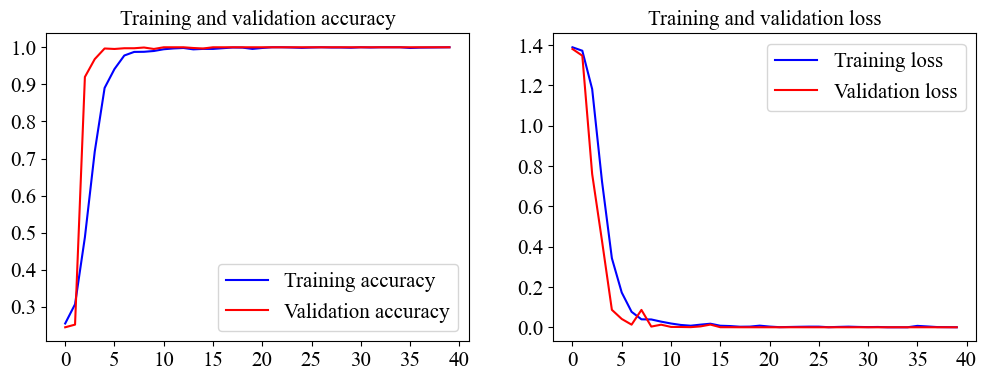

In [6]:
plot_results(history)

In [7]:
# Confusion matrix and heatmap visualization
def plot_confusion_matrix(true_classes, predicted_classes, class_labels):
    """
    Create and display a confusion matrix heatmap for model evaluation.

    Parameters:
        true_classes (array-like): Ground truth labels for the test data
        predicted_classes (array-like): Model's predicted labels for the test data
        class_labels (list): List of class names for axis labels

    The function creates a heatmap visualization where:
    - Rows represent true labels
    - Columns represent predicted labels
    - Each cell shows the count of predictions
    - Darker colors indicate higher values
    """
    cm = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(6, 4))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels, 
                annot_kws={"size": 15},
                cbar_kws={'shrink': 0.8})
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=18)
    plt.ylabel('True Label', fontsize=20)
    plt.xlabel('Predicted Label', fontsize=20)
    plt.title('Confusion Matrix', fontsize=20)
    plt.xticks(fontsize=20, rotation=45)
    plt.yticks(fontsize=20, rotation=0)
    plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


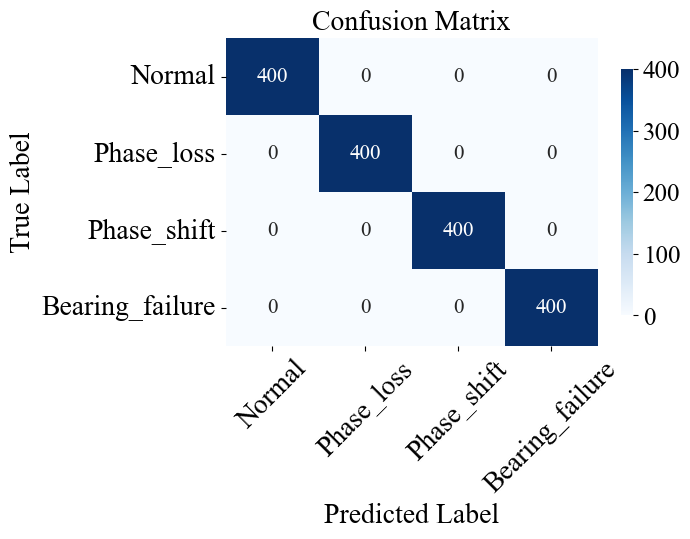

                 precision    recall  f1-score   support

         Normal       1.00      1.00      1.00       400
     Phase_loss       1.00      1.00      1.00       400
    Phase_shift       1.00      1.00      1.00       400
Bearing_failure       1.00      1.00      1.00       400

       accuracy                           1.00      1600
      macro avg       1.00      1.00      1.00      1600
   weighted avg       1.00      1.00      1.00      1600



In [8]:
# Evaluation: predictions, confusion matrix heatmap, and overall accuracy
steps = math.ceil(test_generator.samples / test_generator.batch_size)
predictions = model.predict(test_generator, steps=steps)
predicted_classes = np.argmax(predictions, axis=1)
predicted_classes = predicted_classes[:test_generator.samples] 
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Call the function to plot confusion matrix
plot_confusion_matrix(true_classes, predicted_classes, class_labels)
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

In [ ]:
# Imports (ensure available)
import tensorflow as tf
import numpy as np
import shutil, subprocess, traceback

# preprocessing (unchanged)
from tensorflow.keras.preprocessing.image import img_to_array

def prepare(img):
    x = img_to_array(img)
    x = x / 255.0
    # ensure channel dimension for grayscale images
    if x.ndim == 2:
        x = np.expand_dims(x, -1)
    x = x.astype(np.float32)
    return x

# create ImageDataGenerator for representative samples
path_data = 'MCMD-2025/train/'
repDatagen = tf.keras.preprocessing.image.ImageDataGenerator(preprocessing_function=prepare)
datagen = repDatagen.flow_from_directory(
    path_data,
    target_size=(64, 64),
    color_mode='grayscale',
    batch_size=1,
    class_mode=None,
    shuffle=True
)

# create concrete function from model
# Note: if the model input shape is (None, 64,64,1) then the concrete function signature with batch=1 will be (1,64,64,1)
input_signature = tf.TensorSpec([1, 64, 64, 1], tf.float32)
concrete_func = tf.function(model).get_concrete_function(input_signature)

# converter from concrete function
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func])

# representative dataset generator
def representative_dataset_gen():
    # limit calibration samples (e.g., 100)
    for i in range(100):
        try:
            batch = next(datagen)
        except Exception:
            try:
                batch = datagen.next()
            except Exception as e:
                print('Failed to get batch from datagen at iteration', i)
                raise
        # flow_from_directory with class_mode=None returns only x (shape (1,H,W,C))
        if isinstance(batch, (tuple, list)):
            x = batch[0]
        else:
            x = batch
        sample = x[0].astype(np.float32)       # shape (H,W,C)
        # ensure correct shape (64,64,1)
        if sample.ndim == 2:
            sample = np.expand_dims(sample, -1)
        if i < 5:
            print(f'representative sample {i} shape:', sample.shape, 'dtype:', sample.dtype)
        # converter expects each yield to be a list containing a np.array with a batch dimension
        yield [np.expand_dims(sample, 0)]     # shape (1,64,64,1)

# quantization configuration
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
# require int8 ops & I/O
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.target_spec.supported_types = [tf.int8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# convert and save
model_file = 'model_quant_int8.tflite'
try:
    print("Converting to TFLite (INT8) ...")
    tflite_model_quant = converter.convert()
    with open(model_file, 'wb') as f:
        f.write(tflite_model_quant)
    print('Wrote TFLite model to', model_file)
except Exception:
    print('Error during converter.convert():')
    traceback.print_exc()
    raise

# generate C source (xxd fallback)
out_cc = model_file.replace('.tflite', '.cc')
if shutil.which('xxd'):
    subprocess.run(['xxd', '-i', model_file, out_cc], check=True)
    print('Wrote C source with xxd to', out_cc)
else:
    data = open(model_file, 'rb').read()
    with open(out_cc, 'w') as f:
        f.write('#include <stdint.h>\n\n')
        array_name = model_file.replace('.', '_').replace('-', '_')
        f.write(f'unsigned char {array_name}[] = {{\n')
        for i in range(0, len(data), 12):
            chunk = data[i:i+12]
            f.write('  ' + ', '.join(str(b) for b in chunk) + ',\n')
        f.write('};\n\n')
        f.write(f'unsigned int {array_name}_len = {len(data)};\n')
    print('Wrote C source fallback to', out_cc)


Found 4800 images belonging to 4 classes.


Converting to TFLite (INT8) ...


2025-11-04 15:00:29.803912: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2025-11-04 15:00:29.804058: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2025-11-04 15:00:29.804508: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-04 15:00:29.804520: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/baotoan/miniconda3/envs/env_tensorflow/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:964: UserWarning: Statistics for quantized inputs were expected, b

representative sample 0 shape: (64, 64, 1) dtype: float32
representative sample 1 shape: (64, 64, 1) dtype: float32
representative sample 2 shape: (64, 64, 1) dtype: float32
representative sample 3 shape: (64, 64, 1) dtype: float32
representative sample 4 shape: (64, 64, 1) dtype: float32


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
2025-11-04 15:00:30.171525: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3064] Estimated count of arithmetic ops: 5.391 M  ops, equivalently 2.695 M  MACs


Wrote TFLite model to model_quant_int8.tflite
Wrote C source with xxd to model_quant_int8.cc


Input details: [{'name': 'args_0', 'index': 0, 'shape': array([ 1, 64, 64,  1], dtype=int32), 'shape_signature': array([ 1, 64, 64,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.0038908112328499556, -128), 'quantization_parameters': {'scales': array([0.00389081], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'Identity', 'index': 25, 'shape': array([1, 4], dtype=int32), 'shape_signature': array([1, 4], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Found 1600 images belonging to 4 classes.
Running inference on 1600 samples


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


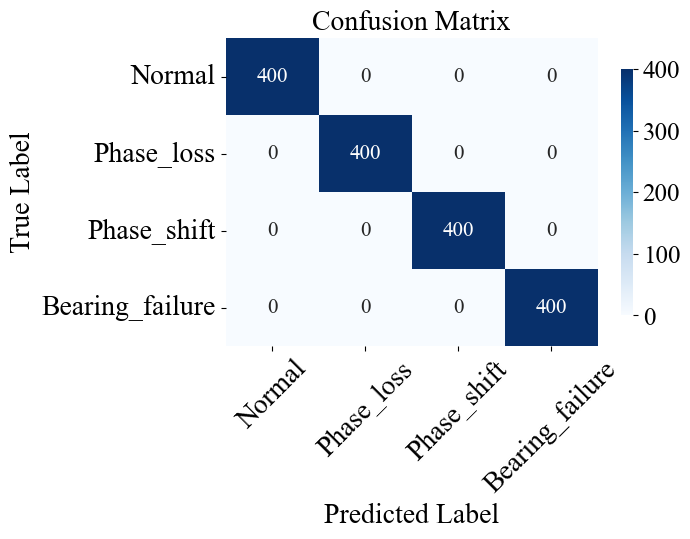

                 precision    recall  f1-score   support

         Normal       1.00      1.00      1.00       400
     Phase_loss       1.00      1.00      1.00       400
    Phase_shift       1.00      1.00      1.00       400
Bearing_failure       1.00      1.00      1.00       400

       accuracy                           1.00      1600
      macro avg       1.00      1.00      1.00      1600
   weighted avg       1.00      1.00      1.00      1600



In [10]:
# TFLite INT8 inference and evaluation on test set
# This cell loads the quantized TFLite model `model_quant_int8.tflite`, runs inference
# on the test_generator images (batch_size=1), and prints a confusion matrix + report.

model_path = 'model_quant_int8.tflite'

# Load TFLite model
# load interpreter with XNNPACK disabled for compatibility
interpreter = tf.lite.Interpreter(
        model_path=model_path,
        experimental_delegates=None,
        experimental_preserve_all_tensors=False
    )
interpreter.allocate_tensors()

# Get input/output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print('Input details:', input_details)
print('Output details:', output_details)

# Helper to run single image through interpreter, handling int8 I/O
# image expected as float32 in [0,1] and shape (64,64,1)
def run_tflite_inference(image):
    in_det = input_details[0]
    out_det = output_details[0]

    scale, zero_point = in_det['quantization']

    input_data = (image.astype(np.float32) / scale) + zero_point
    input_data = input_data.astype(in_det['dtype'])

    # Add batch dimension if missing
    if input_data.ndim == 3:
        input_data = np.expand_dims(input_data, 0)

    interpreter.set_tensor(in_det['index'], input_data)
    interpreter.invoke()

    output_data = interpreter.get_tensor(out_det['index'])

    # Dequantize output if needed
    if out_det['dtype'] in (np.int8, np.uint8):
        o_scale, o_zero_point = out_det['quantization']
        preds = (output_data.astype(np.float32) - o_zero_point) * o_scale
    else:
        preds = output_data
    return preds

# Ensure test_generator yields images scaled the same way (1./255) and batch_size=1
if test_generator.batch_size != 1:
    test_gen_single = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(64,64),
        color_mode='grayscale',
        class_mode='categorical',
        classes=classes,
        batch_size=1,
        shuffle=False
    )
else:
    test_gen_single = test_generator

n_samples = test_gen_single.samples
print('Running inference on', n_samples, 'samples')

y_true = []
y_pred = []

for i in range(n_samples):
    x_batch, y_batch = next(test_gen_single)
    # x_batch shape (1,64,64,1) and rescaled by test_datagen
    img = x_batch[0]
    preds = run_tflite_inference(img)
    # preds typically shape (1, num_classes)
    pred_class = np.argmax(preds, axis=1)[0]
    true_class = np.argmax(y_batch, axis=1)[0]
    y_pred.append(pred_class)
    y_true.append(true_class)

labels = list(test_gen_single.class_indices.keys())
plot_confusion_matrix(y_true, y_pred, labels)
print(classification_report(y_true, y_pred, target_names=labels))
